# Deconvolved Data Replication Timing from 10k MNase-seq Windows

April 24, 2024

Compute the replicating timing from the deconvolved MNase-seq 10k windows for each gene.

This will require a tuning of the alpha parameter.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves_and_expression_correlations()
mnase_analysis_rep1.compute_replication_timing()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:15.976


In [90]:
mnase_analysis_rep2 = MNaseOriginAnalysis(replicate=2)
mnase_analysis_rep2.compute_bin_curves()


In [95]:
mnase_analysis_rep2.compute_replication_timing()

In [97]:
mnase_analysis_rep1.load_posteriors_for_timing()
mnase_analysis_rep2.load_posteriors_for_timing()

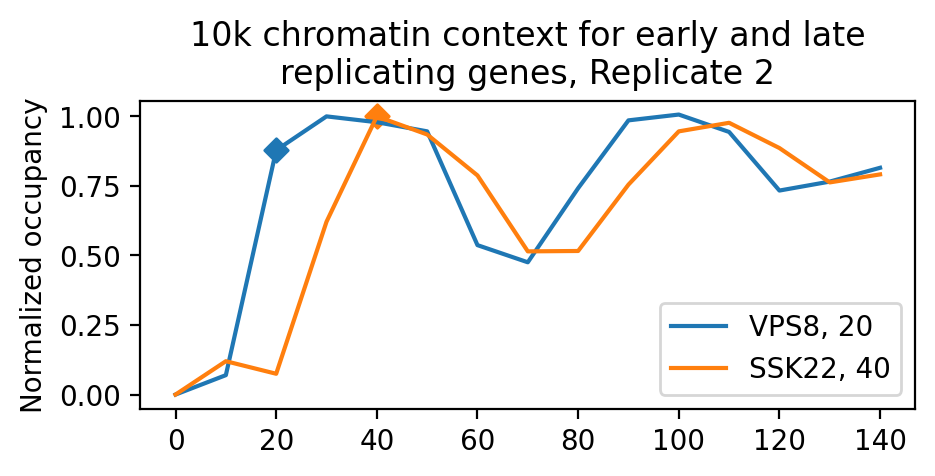

In [98]:
mnase_analysis_rep2.plot_normalized_bin_curves(['VPS8', 'SSK22'])

In [99]:
from src.deconv_replication_timing import DeconvReplicationProfileAnalysis

deconv_rep_analysis1 = DeconvReplicationProfileAnalysis(mnase_analysis_rep1, mnase_analysis_rep2)
deconv_rep_analysis2 = DeconvReplicationProfileAnalysis(mnase_analysis_rep1, mnase_analysis_rep2)

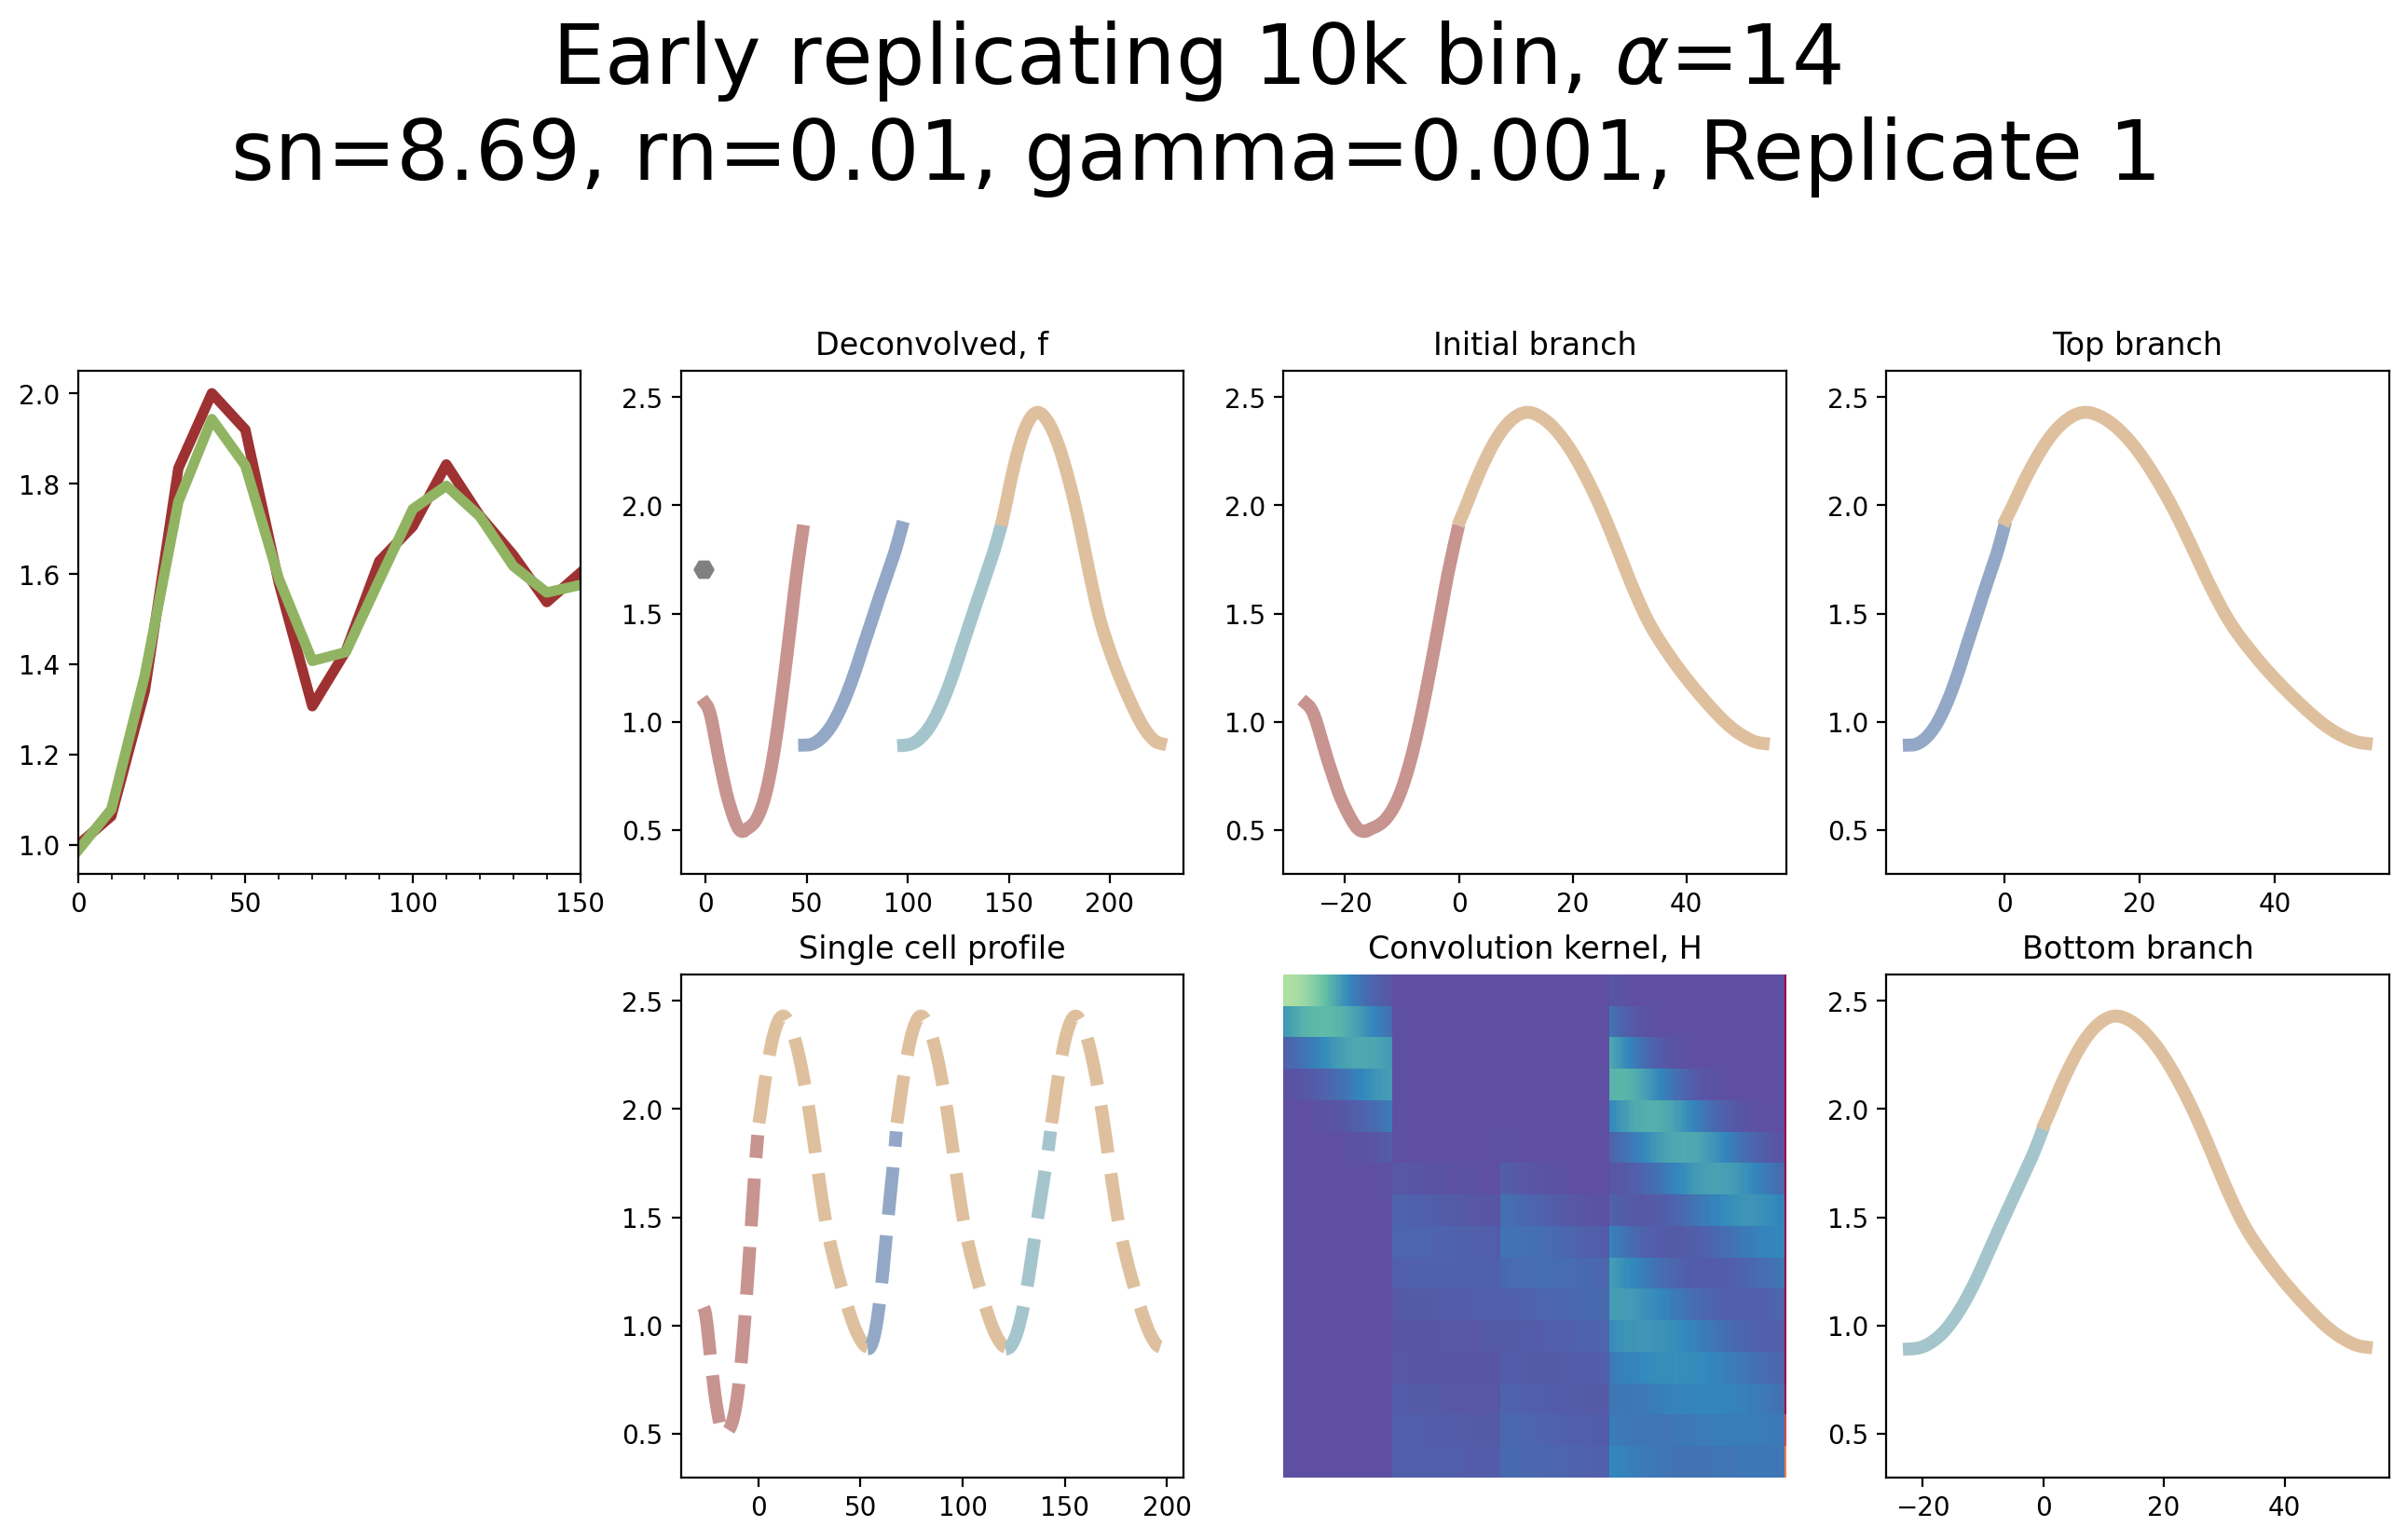

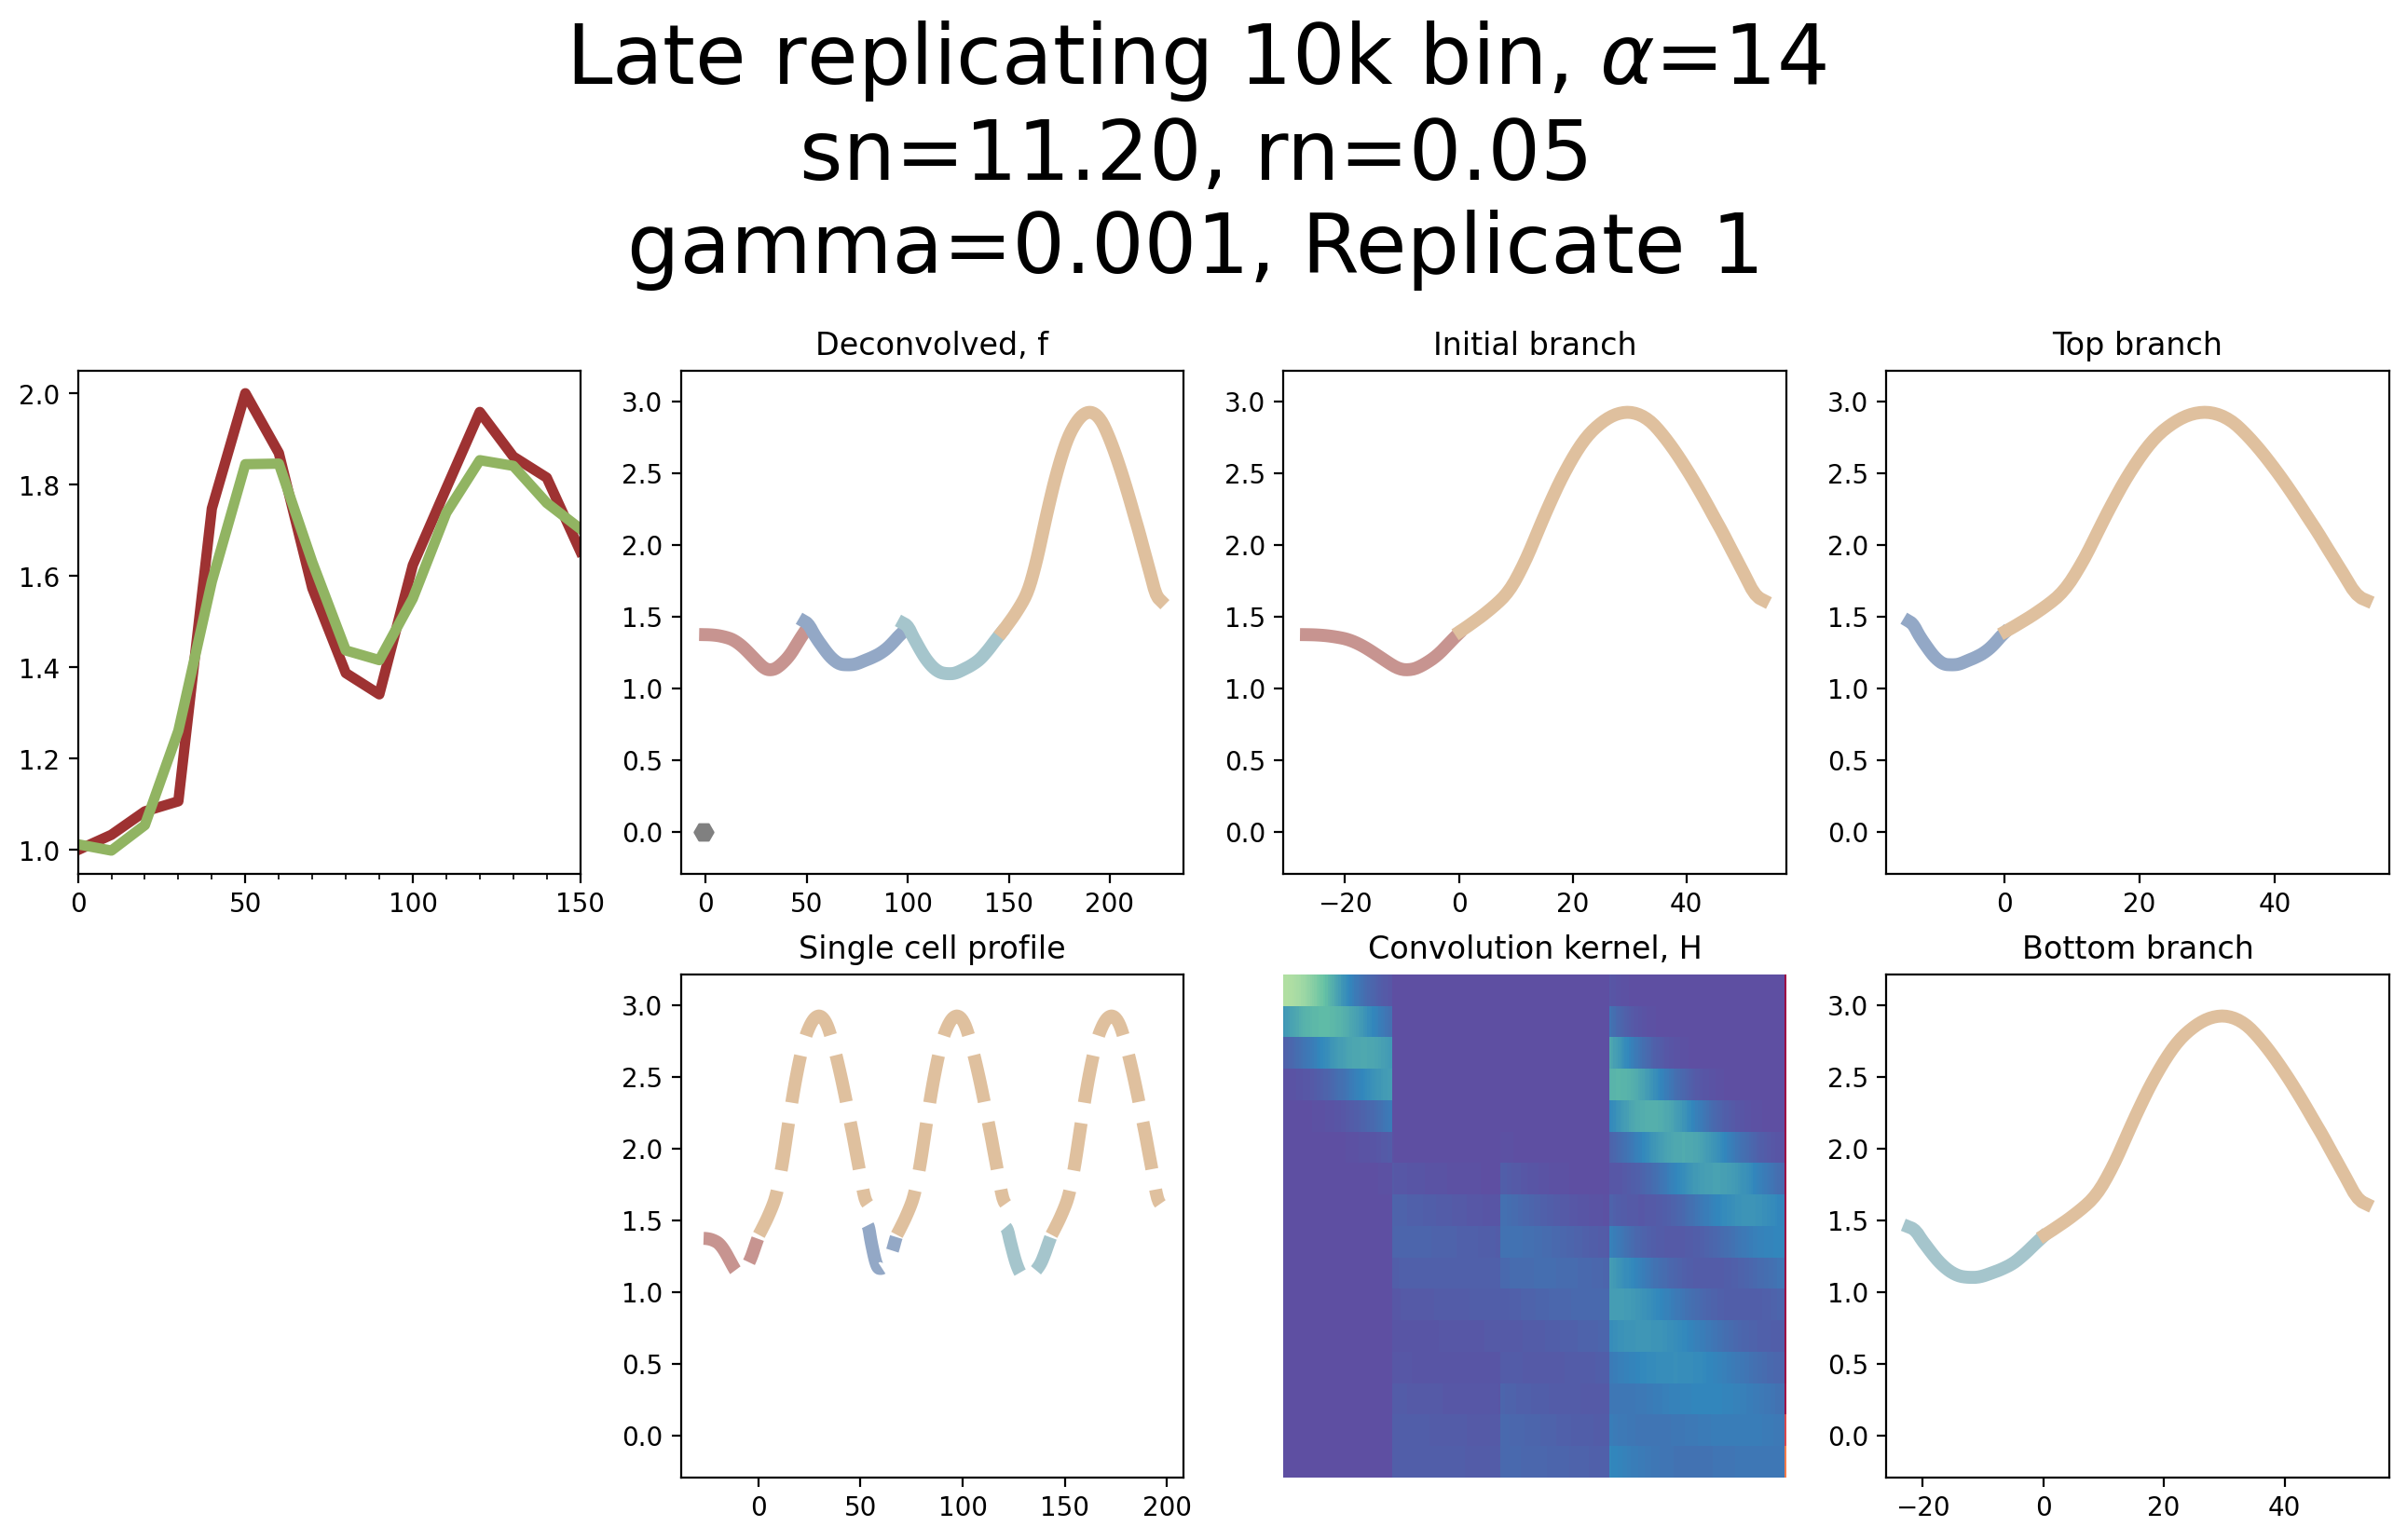

In [57]:
deconv_rep_analysis1.compare_early_late_deconv_bin_curves(14, 1)

In [102]:
deconv_rep_analysis1.create_chr_bin_curves(1, 4)
deconv_rep_analysis2.create_chr_bin_curves(2, 4)

Setting up bin curves for replicate 1, chromosome 4
Setting up model with temporary gene. (Actual deconvolution will use chrom bin curves, not gene data)...
Loading MNase reads for YMR199W/CLN1...Loading chromosome reads: 13
Done.
Setting up bin curves for replicate 2, chromosome 4
Setting up model with temporary gene. (Actual deconvolution will use chrom bin curves, not gene data)...
Loading MNase reads for YMR199W/CLN1...Loading chromosome reads: 13
Done.


In [ ]:
deconv_rep_analysis1.alpha_search(alphas=[0, 14, 28])

0/3, alpha=0
Deconvolving with gamma=0.001, gamma_prime=0


In [ ]:
deconv_rep_analysis2.alpha_search(alphas=[0, 14, 28])

In [ ]:
pd.DataFrame(deconv_rep_analysis1.alphas).to_csv("output/alpha_search_mnase/rep1_alpha.csv")
pd.DataFrame(deconv_rep_analysis2.alphas).to_csv("output/alpha_search_mnase/rep2_alpha.csv")

In [ ]:
np.save("output/alpha_search_mnase/rep1_alpha_fs.npy", deconv_rep_analysis1.alpha_fs)
np.save("output/alpha_search_mnase/rep2_alpha_fs.npy", deconv_rep_analysis2.alpha_fs)

In [ ]:
deconv_rep_analysis1.plot_alpha_search_results()

In [ ]:
deconv_rep_analysis2.plot_alpha_search_results()

In [ ]:
deconv_rep_analysis1.plot_example_alpha_repl_timing(1)

In [ ]:
deconv_rep_analysis2.plot_example_alpha_repl_timing(1)